# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Load the Datasets

In [3]:
application_df = pd.read_csv("application_record.csv")

credit_df = pd.read_csv("credit_record.csv")

# View the First Five Rows

In [4]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


# Check Dataset Shape

In [6]:
print("Application Dataset Shape:", application_df.shape)

print("Credit Dataset Shape:", credit_df.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


# Check Column Names

In [7]:
application_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='str')

In [8]:
credit_df.columns

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='str')

# Check Data Types

In [9]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [10]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


# Check Missing Values

In [11]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [12]:
credit_df.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

# Check Duplicate Rows

In [13]:
print("Application duplicates:", application_df.duplicated().sum())

print("Credit duplicates:", credit_df.duplicated().sum())

Application duplicates: 0
Credit duplicates: 0


# Statistical Summary

In [14]:
application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [15]:
application_df.describe(include='object')

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,438557,438557,438557,438557,438557,438557,438557,304354
unique,2,2,2,5,5,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,294440,275459,304074,226104,301821,299828,393831,78240


# Understand the Credit Status

In [16]:
credit_df['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

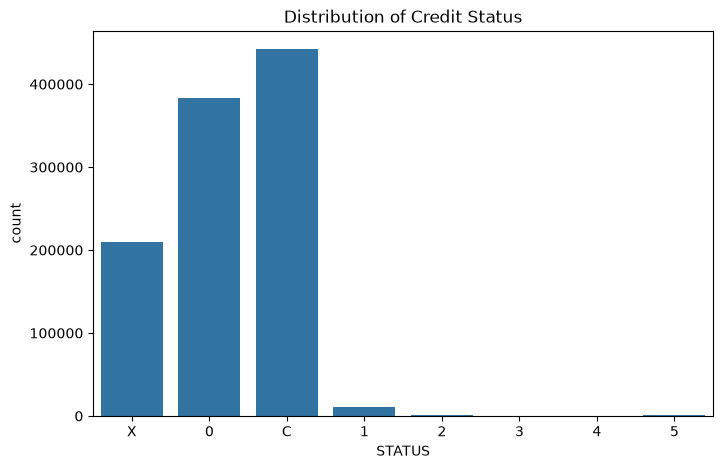

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='STATUS', data=credit_df)

plt.title("Distribution of Credit Status")

plt.show()

# 2 Data Preprocessing
## 2.1 Explore Unique Values

In [18]:
# Check unique values in each column
for col in application_df.columns:
    print(f"\n{col}")
    print(application_df[col].unique())


ID
[5008804 5008805 5008806 ... 6841878 6842765 6842885]

CODE_GENDER
<StringArray>
['M', 'F']
Length: 2, dtype: str

FLAG_OWN_CAR
<StringArray>
['Y', 'N']
Length: 2, dtype: str

FLAG_OWN_REALTY
<StringArray>
['Y', 'N']
Length: 2, dtype: str

CNT_CHILDREN
[ 0  1  3  2  4  5 14 19  7  9 12  6]

AMT_INCOME_TOTAL
[ 427500.    112500.    270000.    283500.    135000.    130500.
  157500.    405000.    211500.    360000.    126000.    315000.
  247500.    297000.    225000.    166500.    216000.    255150.
  148500.    202500.     94500.    450000.    180000.     90000.
  765000.    382500.    144000.    229500.    292500.     74250.
   40500.    337500.    193500.    267750.    139500.     67500.
  252000.    900000.    115290.    279000.     76500.    234000.
   81000.    108000.     99000.    198000.     45000.    238500.
  117000.    153000.   1350000.    445500.    495000.     85500.
  306000.    562500.    189000.    328500.    310500.    540000.
  171000.    675000.    121500.     7

In [19]:
application_df.nunique()

ID                     438510
CODE_GENDER                 2
FLAG_OWN_CAR                2
FLAG_OWN_REALTY             2
CNT_CHILDREN               12
AMT_INCOME_TOTAL          866
NAME_INCOME_TYPE            5
NAME_EDUCATION_TYPE         5
NAME_FAMILY_STATUS          5
NAME_HOUSING_TYPE           6
DAYS_BIRTH              16379
DAYS_EMPLOYED            9406
FLAG_MOBIL                  1
FLAG_WORK_PHONE             2
FLAG_PHONE                  2
FLAG_EMAIL                  2
OCCUPATION_TYPE            18
CNT_FAM_MEMBERS            13
dtype: int64

In [20]:
credit_df['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

# 2.2 Handle Missing Values

In [21]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [22]:
application_df['OCCUPATION_TYPE'] = application_df['OCCUPATION_TYPE'].fillna('Unknown')

In [23]:
application_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64

# 2.3 Create the Target Variable

In [24]:
def create_target(status):
    if status in ['2', '3', '4', '5']:
        return 1   # Bad Customer
    else:
        return 0   # Good Customer

In [25]:
credit_df['TARGET'] = credit_df['STATUS'].apply(create_target)

In [26]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


# 2.4 Aggregate the Credit Records

In [27]:
credit_target = credit_df.groupby('ID')['TARGET'].max().reset_index()

In [28]:
credit_target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [29]:
credit_target.shape

(45985, 2)

# 2.5 Merge the Datasets

In [30]:
final_df = application_df.merge(credit_target, on='ID', how='inner')

In [31]:
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [32]:
print(final_df.shape)

(36457, 19)


# 2.6 Check the Target Distribution

In [33]:
final_df['TARGET'].value_counts()

TARGET
0    35841
1      616
Name: count, dtype: int64

In [34]:
final_df['TARGET'].value_counts(normalize=True) * 100

TARGET
0    98.310338
1     1.689662
Name: proportion, dtype: float64

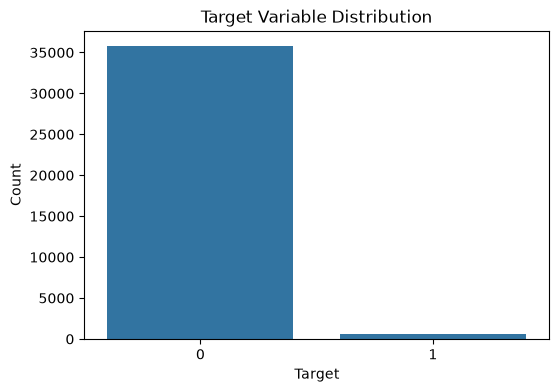

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=final_df)

plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# 2.7 Save the Processed Dataset

In [36]:
final_df.to_csv("credit_card_processed.csv", index=False)

# 3 Exploratory Data Analysis (EDA)
## 3.1 Check Dataset Information

In [37]:
# Display first 5 rows
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [38]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null  int64  
 1

In [39]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


# 3.2 Feature Engineering (Convert Days to Years)

In [40]:
# Convert age from days to years
final_df['AGE'] = (-final_df['DAYS_BIRTH'] / 365).astype(int)

# Convert employment days to years
final_df['YEARS_EMPLOYED'] = final_df['DAYS_EMPLOYED'] / -365

In [41]:
final_df['DAYS_EMPLOYED'] = final_df['DAYS_EMPLOYED'].replace(365243, np.nan)

final_df['YEARS_EMPLOYED'] = (-final_df['DAYS_EMPLOYED'] / 365)

In [42]:
final_df[['AGE', 'YEARS_EMPLOYED']].head()

,AGE,YEARS_EMPLOYED
0,32,12.443836
1,32,12.443836
2,58,3.106849
3,52,8.358904
4,52,8.358904


# 3.3 Distribution of Age

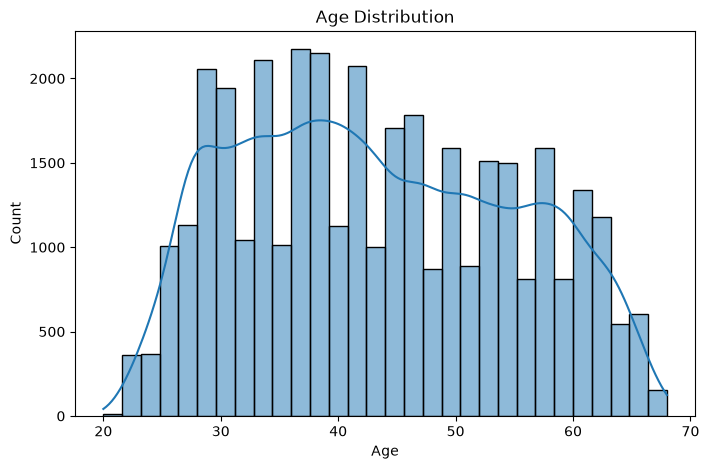

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(final_df['AGE'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# 3.4 Income Distribution

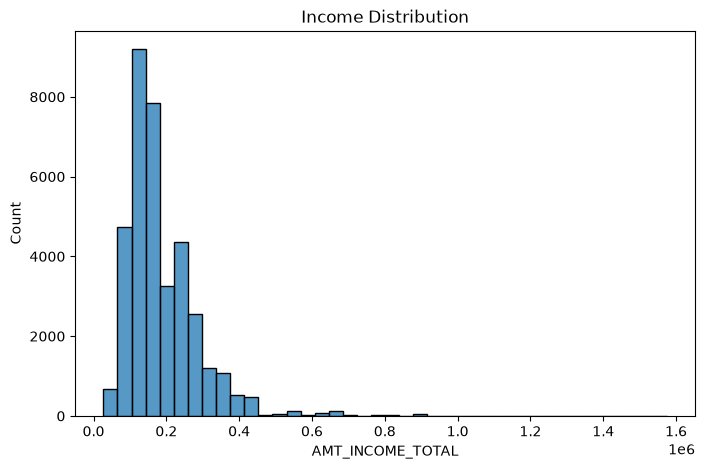

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(final_df['AMT_INCOME_TOTAL'], bins=40)

plt.title("Income Distribution")

plt.show()

# 3.5 Box Plot for Income (Outlier Detection)

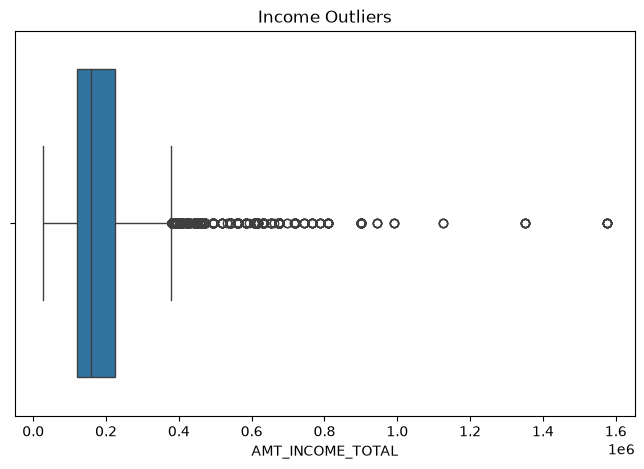

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(x=final_df['AMT_INCOME_TOTAL'])

plt.title("Income Outliers")

plt.show()

# 3.6 Gender Distribution

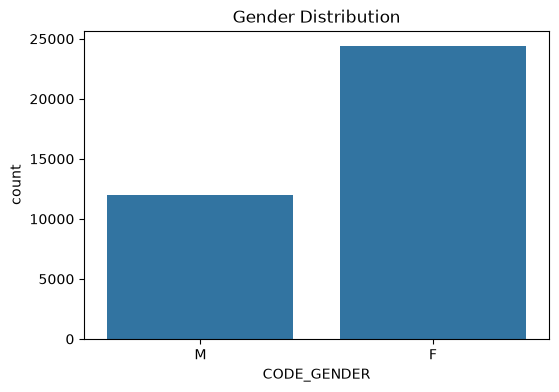

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(x='CODE_GENDER', data=final_df)

plt.title("Gender Distribution")

plt.show()

# 3.7 Income Type Distribution

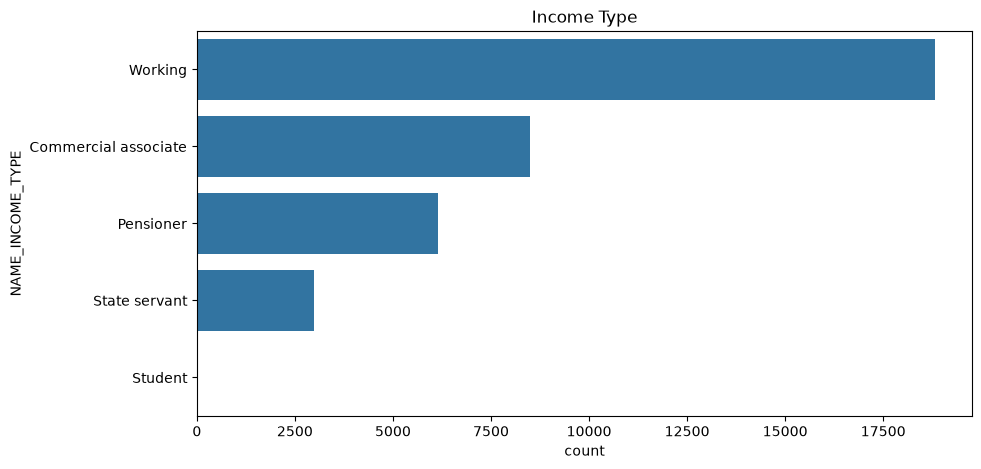

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='NAME_INCOME_TYPE',
    data=final_df,
    order=final_df['NAME_INCOME_TYPE'].value_counts().index
)

plt.title("Income Type")

plt.show()

# 3.8 Education Level

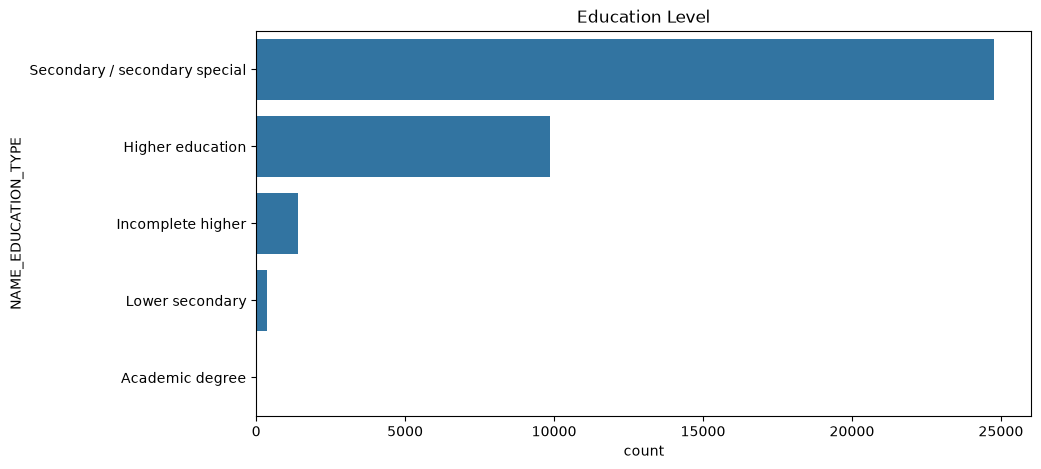

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='NAME_EDUCATION_TYPE',
    data=final_df,
    order=final_df['NAME_EDUCATION_TYPE'].value_counts().index
)

plt.title("Education Level")

plt.show()

# 3.9 Family Status

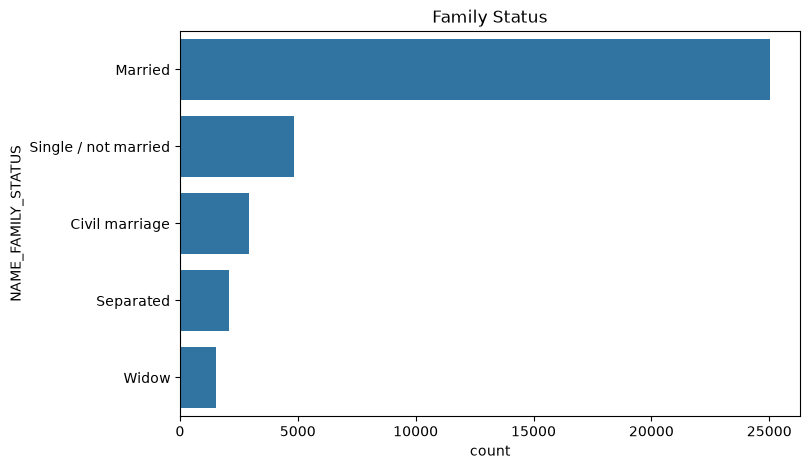

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='NAME_FAMILY_STATUS',
    data=final_df,
    order=final_df['NAME_FAMILY_STATUS'].value_counts().index
)

plt.title("Family Status")

plt.show()

# 3.10 Housing Type

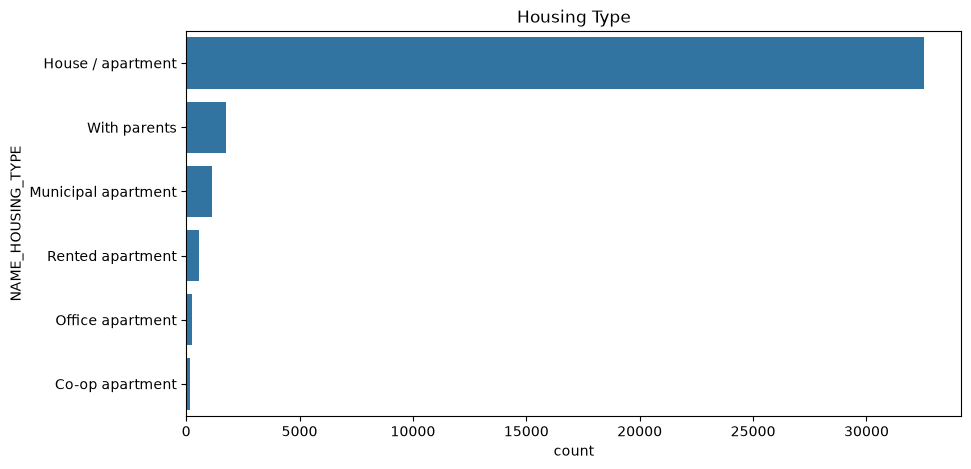

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='NAME_HOUSING_TYPE',
    data=final_df,
    order=final_df['NAME_HOUSING_TYPE'].value_counts().index
)

plt.title("Housing Type")

plt.show()

# 3.11 Target Distribution

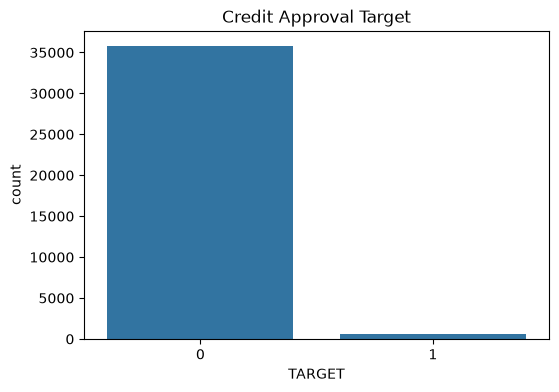

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=final_df)

plt.title("Credit Approval Target")

plt.show()

In [52]:
(final_df['TARGET'].value_counts(normalize=True) * 100).round(2)

TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64

# 3.12 Correlation Matrix

In [53]:
numeric_df = final_df.select_dtypes(include=['int64', 'float64'])

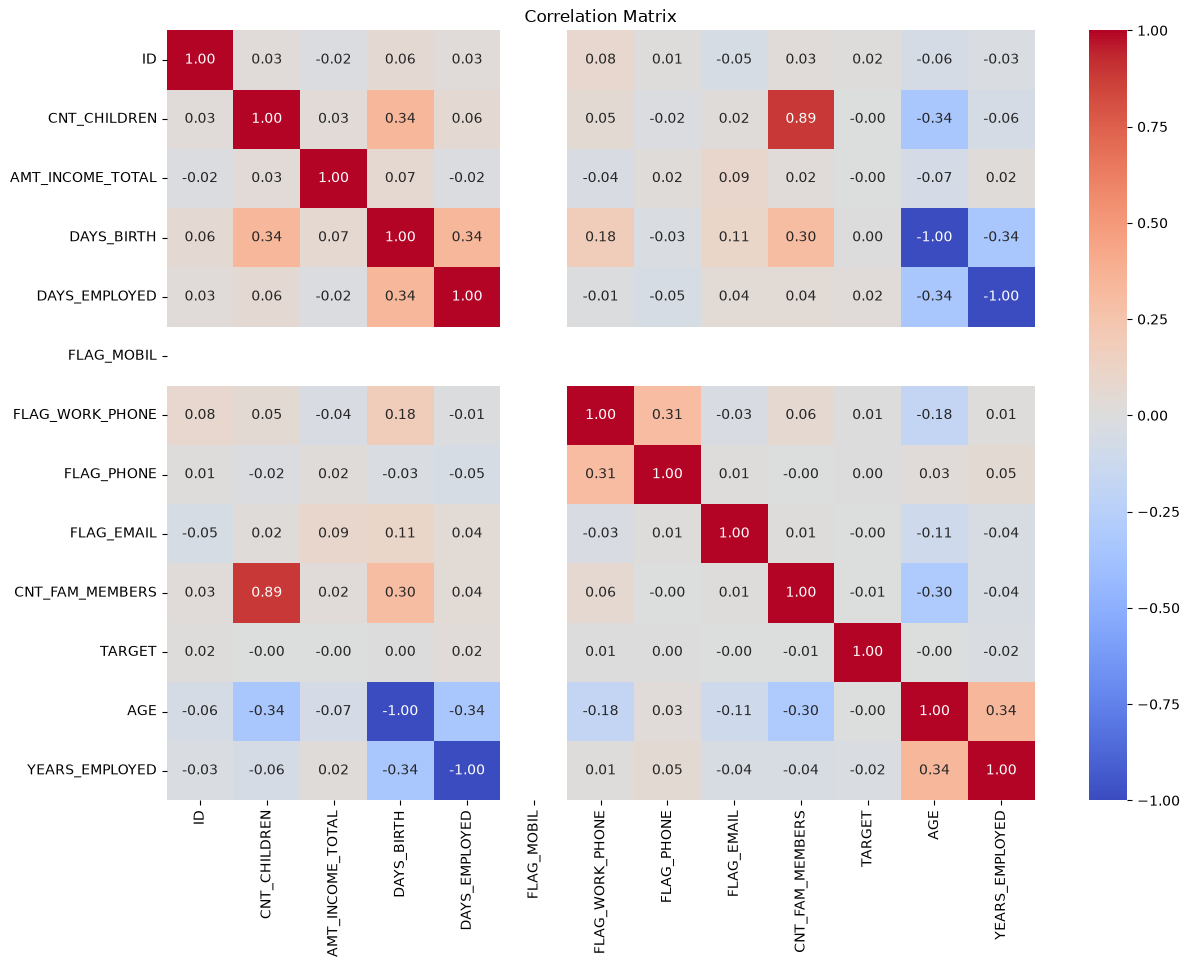

In [54]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# 3.13 Relationship Between Features and Target
## Income vs Target

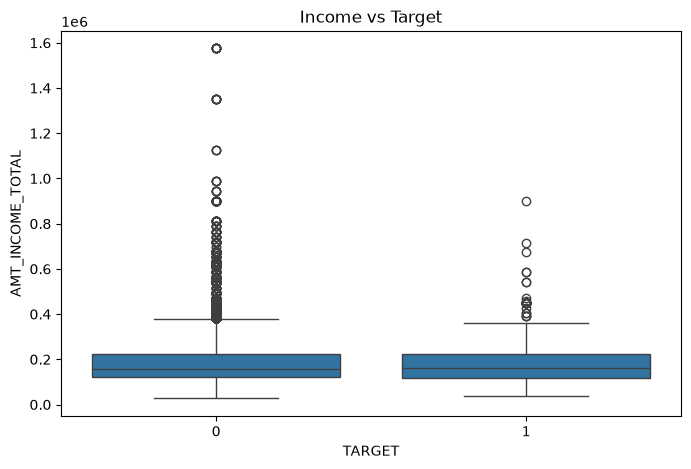

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=final_df)

plt.title("Income vs Target")

plt.show()

# Age vs Target

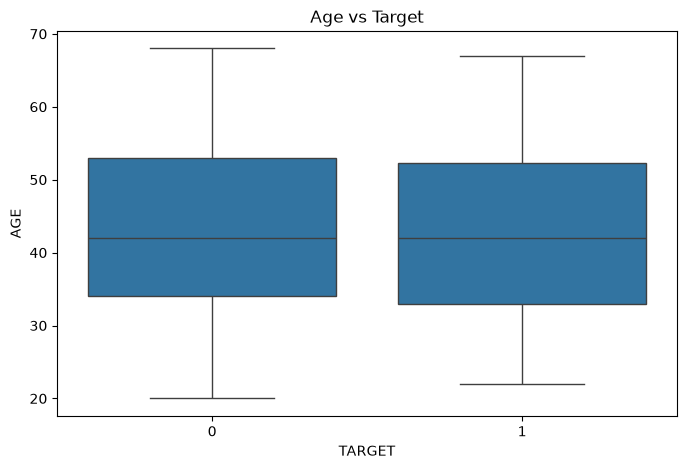

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AGE', data=final_df)

plt.title("Age vs Target")

plt.show()

# Children vs Target

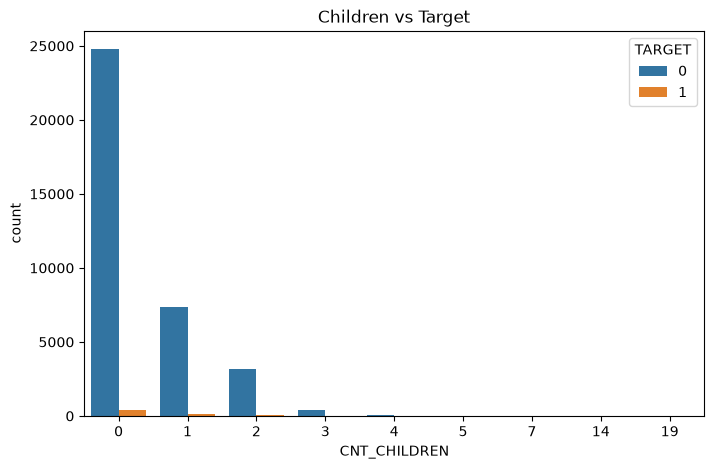

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(x='CNT_CHILDREN', hue='TARGET', data=final_df)

plt.title("Children vs Target")

plt.show()

# 4 Data Preprocessing
## 4.1 Create a Copy of the Dataset

In [58]:
df = final_df.copy()

In [59]:
df.shape

(36457, 21)

# 4.2 Drop Unnecessary Columns

In [60]:
df.drop(['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

In [61]:
df.columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'TARGET', 'AGE', 'YEARS_EMPLOYED'],
      dtype='str')

# 4.3 Check Missing Values Again

In [62]:
df.isnull().sum()

CODE_GENDER               0
FLAG_OWN_CAR              0
FLAG_OWN_REALTY           0
CNT_CHILDREN              0
AMT_INCOME_TOTAL          0
NAME_INCOME_TYPE          0
NAME_EDUCATION_TYPE       0
NAME_FAMILY_STATUS        0
NAME_HOUSING_TYPE         0
FLAG_MOBIL                0
FLAG_WORK_PHONE           0
FLAG_PHONE                0
FLAG_EMAIL                0
OCCUPATION_TYPE           0
CNT_FAM_MEMBERS           0
TARGET                    0
AGE                       0
YEARS_EMPLOYED         6135
dtype: int64

In [63]:
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].fillna(df['YEARS_EMPLOYED'].median())

In [64]:
df.isnull().sum()

CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
AGE                    0
YEARS_EMPLOYED         0
dtype: int64

# 4.4 Identify Categorical and Numerical Columns

In [65]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='str')

Numerical Columns:
Index(['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE',
       'YEARS_EMPLOYED'],
      dtype='str')


# 4.5 Encode Categorical Variables

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
le = LabelEncoder()

In [68]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [69]:
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(final_df[col])      # Use the dataframe BEFORE encoding

    print(f"\n{col}")
    for cls, val in zip(le.classes_, le.transform(le.classes_)):
        print(f"{cls} --> {val}")


CODE_GENDER
F --> 0
M --> 1

FLAG_OWN_CAR
N --> 0
Y --> 1

FLAG_OWN_REALTY
N --> 0
Y --> 1

NAME_INCOME_TYPE
Commercial associate --> 0
Pensioner --> 1
State servant --> 2
Student --> 3
Working --> 4

NAME_EDUCATION_TYPE
Academic degree --> 0
Higher education --> 1
Incomplete higher --> 2
Lower secondary --> 3
Secondary / secondary special --> 4

NAME_FAMILY_STATUS
Civil marriage --> 0
Married --> 1
Separated --> 2
Single / not married --> 3
Widow --> 4

NAME_HOUSING_TYPE
Co-op apartment --> 0
House / apartment --> 1
Municipal apartment --> 2
Office apartment --> 3
Rented apartment --> 4
With parents --> 5

OCCUPATION_TYPE
Accountants --> 0
Cleaning staff --> 1
Cooking staff --> 2
Core staff --> 3
Drivers --> 4
HR staff --> 5
High skill tech staff --> 6
IT staff --> 7
Laborers --> 8
Low-skill Laborers --> 9
Managers --> 10
Medicine staff --> 11
Private service staff --> 12
Realty agents --> 13
Sales staff --> 14
Secretaries --> 15
Security staff --> 16
Unknown --> 17
Waiters/barmen st

In [70]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,0,32,12.443836
1,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,0,32,12.443836
2,1,1,1,0,112500.0,4,4,1,1,1,0,0,0,16,2.0,0,58,3.106849
3,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,0,52,8.358904
4,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,0,52,8.358904


# 4.6 Verify Data Types

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  int64  
 1   FLAG_OWN_CAR         36457 non-null  int64  
 2   FLAG_OWN_REALTY      36457 non-null  int64  
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  int64  
 6   NAME_EDUCATION_TYPE  36457 non-null  int64  
 7   NAME_FAMILY_STATUS   36457 non-null  int64  
 8   NAME_HOUSING_TYPE    36457 non-null  int64  
 9   FLAG_MOBIL           36457 non-null  int64  
 10  FLAG_WORK_PHONE      36457 non-null  int64  
 11  FLAG_PHONE           36457 non-null  int64  
 12  FLAG_EMAIL           36457 non-null  int64  
 13  OCCUPATION_TYPE      36457 non-null  int64  
 14  CNT_FAM_MEMBERS      36457 non-null  float64
 15  TARGET               36457 non-null  int64  
 1

# 4.7 Separate Features and Target

In [72]:
X = df.drop('TARGET', axis=1)

y = df['TARGET']

In [73]:
print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (36457, 17)
Target Shape: (36457,)


# 4.8 Split the Dataset

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
print("Training Set :", X_train.shape)

print("Testing Set :", X_test.shape)

Training Set : (29165, 17)
Testing Set : (7292, 17)


# 4.9 Feature Scaling

In [77]:
from sklearn.preprocessing import StandardScaler

In [78]:
scaler = StandardScaler()

In [79]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [80]:
X_train_scaled

array([[-0.70314639, -0.7842093 ,  0.70037115, ..., -0.21677701,
         1.80356583, -0.25062593],
       [-0.70314639,  1.27516979,  0.70037115, ..., -0.21677701,
        -1.32128199,  0.29564301],
       [ 1.42217897,  1.27516979,  0.70037115, ..., -0.21677701,
         0.06753926,  0.2443002 ],
       ...,
       [ 1.42217897,  1.27516979,  0.70037115, ..., -0.21677701,
        -1.06087801, -0.96803755],
       [ 1.42217897,  1.27516979, -1.42781437, ..., -0.21677701,
         0.58834723,  2.59450552],
       [ 1.42217897,  1.27516979,  0.70037115, ..., -0.21677701,
        -1.23448067, -0.62852748]], shape=(29165, 17))

# 4.10 Save the Processed Dataset

In [81]:
df.to_csv("credit_card_final_dataset.csv", index=False)

# 5 Model Building
## 5.1 Import Required Libraries

In [82]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# 5.2 Create an Evaluation Function

In [83]:
def evaluate_model(model, X_test, y_test):
    
    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Precision
    precision = precision_score(y_test, y_pred)

    # Recall
    recall = recall_score(y_test, y_pred)

    # F1 Score
    f1 = f1_score(y_test, y_pred)

    print("="*50)
    print(model.__class__.__name__)
    print("="*50)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report\n")
    print(classification_report(y_test,y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
    plt.show()

# 5.3 Logistic Regression

In [84]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

LogisticRegression
Accuracy : 0.9831
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



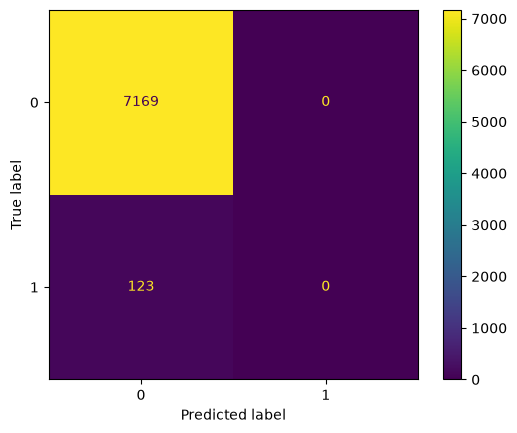

In [85]:
evaluate_model(lr, X_test_scaled, y_test)

# 5.4 Decision Tree Classifier

In [86]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

DecisionTreeClassifier
Accuracy : 0.9827
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



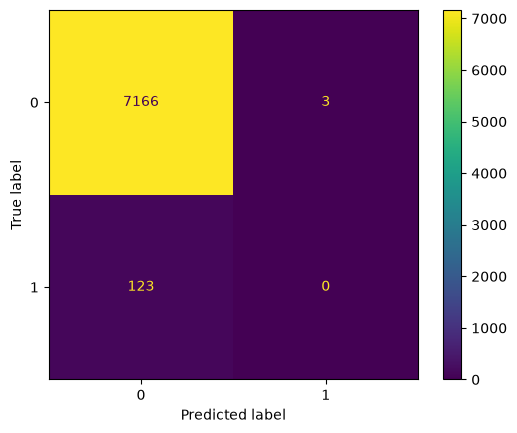

In [87]:
evaluate_model(dt, X_test, y_test)

# 5.5 Random Forest Classifier

In [88]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

RandomForestClassifier
Accuracy : 0.9812
Precision: 0.3654
Recall   : 0.1545
F1 Score : 0.2171

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7169
           1       0.37      0.15      0.22       123

    accuracy                           0.98      7292
   macro avg       0.68      0.57      0.60      7292
weighted avg       0.98      0.98      0.98      7292



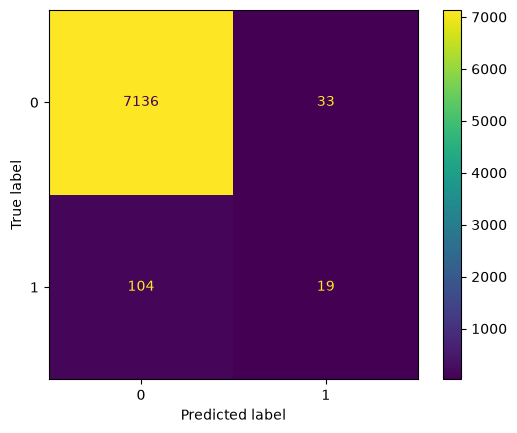

In [89]:
evaluate_model(rf, X_test, y_test)

# 5.6 K-Nearest Neighbors

In [90]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


KNeighborsClassifier
Accuracy : 0.9815
Precision: 0.3
Recall   : 0.0732
F1 Score : 0.1176

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.30      0.07      0.12       123

    accuracy                           0.98      7292
   macro avg       0.64      0.54      0.55      7292
weighted avg       0.97      0.98      0.98      7292



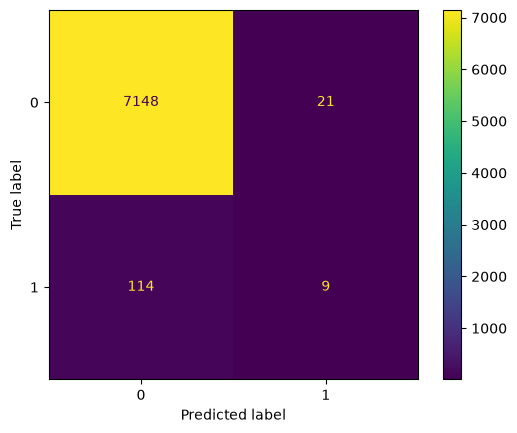

In [91]:
evaluate_model(knn, X_test_scaled, y_test)

# 5.7 Support Vector Machine

In [92]:
svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


SVC
Accuracy : 0.9831
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



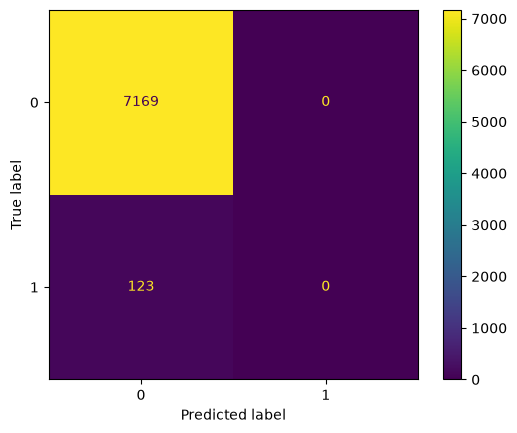

In [93]:
evaluate_model(svm, X_test_scaled, y_test)

# 5.8 Compare All Models

In [94]:
results = pd.DataFrame({
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
})

In [95]:
def compare_models(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)

    global results

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ]

In [96]:
compare_models("Logistic Regression", lr, X_test_scaled, y_test)

compare_models("Decision Tree", dt, X_test, y_test)

compare_models("Random Forest", rf, X_test, y_test)

compare_models("KNN", knn, X_test_scaled, y_test)

compare_models("SVM", svm, X_test_scaled, y_test)

In [97]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.983132,0.000000,0.000000,0.000000
4,SVM,0.983132,0.000000,0.000000,0.000000
1,Decision Tree,0.982721,0.000000,0.000000,0.000000
3,KNN,0.981487,0.300000,0.073171,0.117647
2,Random Forest,0.981212,0.365385,0.154472,0.217143


# 5.9 Feature Importance (Random Forest)

In [98]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [99]:
feature_importance.head(10)

,Feature,Importance
16,YEARS_EMPLOYED,0.204176
4,AMT_INCOME_TOTAL,0.172544
15,AGE,0.172098
13,OCCUPATION_TYPE,0.072951
7,NAME_FAMILY_STATUS,0.058404
14,CNT_FAM_MEMBERS,0.045778
5,NAME_INCOME_TYPE,0.044371
6,NAME_EDUCATION_TYPE,0.035968
1,FLAG_OWN_CAR,0.030533
3,CNT_CHILDREN,0.028644


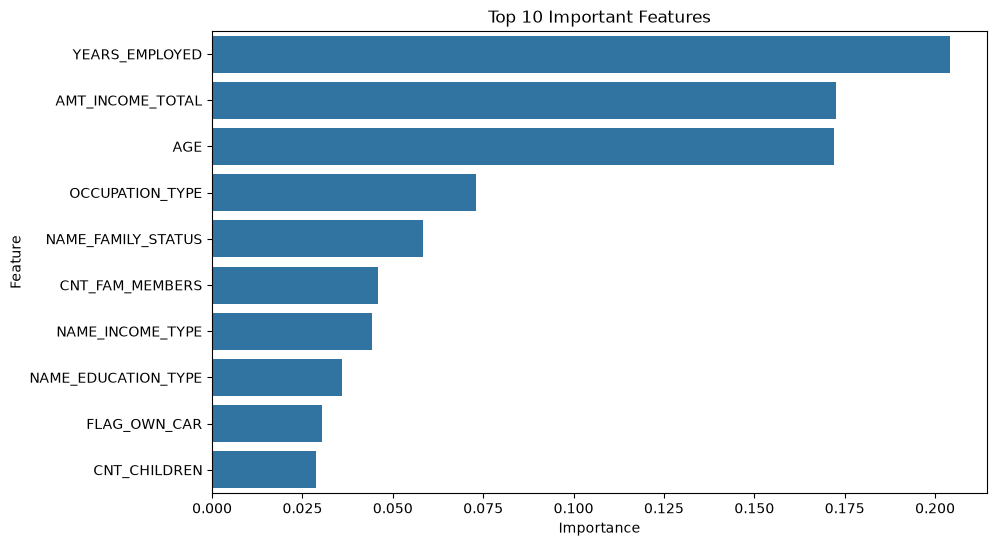

In [100]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [101]:
#### improving model
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7136   33]
 [ 104   19]]


In [102]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8063330486840927

In [103]:
from imblearn.over_sampling import SMOTE

In [104]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [105]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

TARGET
0    28672
1      493
Name: count, dtype: int64
TARGET
0    28672
1    28672
Name: count, dtype: int64


RandomForestClassifier
Accuracy : 0.9723
Precision: 0.2199
Recall   : 0.252
F1 Score : 0.2348

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7169
           1       0.22      0.25      0.23       123

    accuracy                           0.97      7292
   macro avg       0.60      0.62      0.61      7292
weighted avg       0.97      0.97      0.97      7292



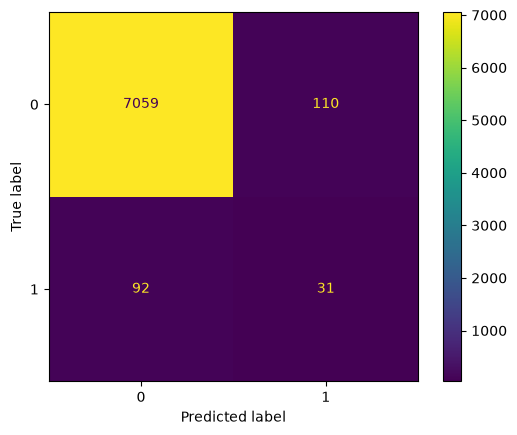

In [106]:
## training random forest agsin
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

evaluate_model(rf_smote, X_test, y_test)

In [107]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

In [108]:
final_df['TARGET'].value_counts()

TARGET
0    35841
1      616
Name: count, dtype: int64

In [109]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [110]:
y_pred = rf.predict(X_test)

In [111]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7136   33]
 [ 104   19]]


In [112]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)

confusion_matrix(y_test, y_pred)

array([[7059,  110],
       [  92,   31]])

In [113]:
confusion_matrix(y_test, rf.predict(X_test))

array([[7136,   33],
       [ 104,   19]])

# Hyperparameter Tuning (Random Forest)
## 6.1 Import Required Libraries

In [114]:
from sklearn.model_selection import RandomizedSearchCV

# 6.2 Define the Parameter Grid

In [115]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# 6.3 Create the Base Model

In [116]:
rf = RandomForestClassifier(random_state=42)

# 6.4 Perform Randomized Search

In [117]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [118]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END class_weight=None, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   7.0s
[CV] END class_weight=None, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   7.6s
[CV] END class_weight=None, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   7.8s
[CV] END class_weight=None, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   7.6s
[CV] END class_weight=None, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   7.7s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  20.8s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  21.8s
[CV] END clas

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

# 6.5 View the Best Parameters

In [119]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced'}


# 6.6 Best Model

In [120]:
best_rf = random_search.best_estimator_

RandomForestClassifier
Accuracy : 0.9554
Precision: 0.1721
Recall   : 0.4309
F1 Score : 0.2459

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7169
           1       0.17      0.43      0.25       123

    accuracy                           0.96      7292
   macro avg       0.58      0.70      0.61      7292
weighted avg       0.98      0.96      0.96      7292



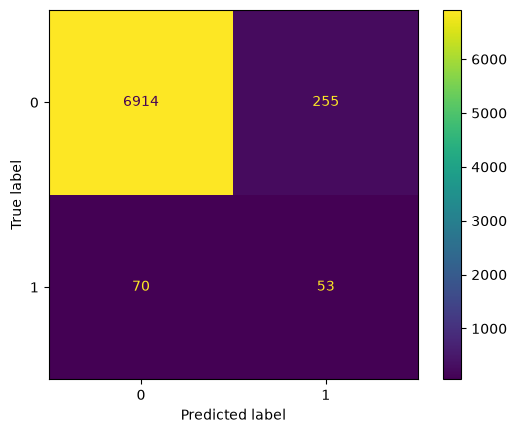

In [121]:
evaluate_model(best_rf, X_test, y_test)

# 6.7 Confusion Matrix

In [122]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_rf.predict(X_test))

print(cm)

[[6914  255]
 [  70   53]]


# 6.8 ROC-AUC Score

In [123]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7468748121711932


# 7 Feature Importance

In [124]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
16,YEARS_EMPLOYED,0.199005
15,AGE,0.173118
4,AMT_INCOME_TOTAL,0.172019
13,OCCUPATION_TYPE,0.089456
7,NAME_FAMILY_STATUS,0.044088
5,NAME_INCOME_TYPE,0.042275
14,CNT_FAM_MEMBERS,0.041467
6,NAME_EDUCATION_TYPE,0.038252
1,FLAG_OWN_CAR,0.031210
3,CNT_CHILDREN,0.030717


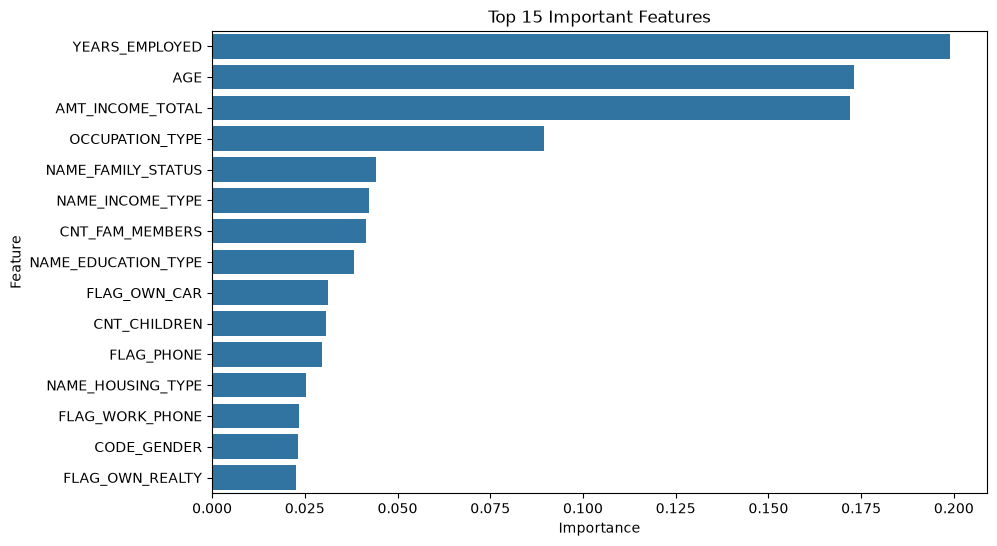

In [125]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title("Top 15 Important Features")
plt.show()

# 8 Save the Best Model

In [126]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [127]:
import joblib

In [128]:
joblib.dump(best_rf, "credit_card_approval_model.pkl")

['credit_card_approval_model.pkl']

In [129]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# 9 Load the Saved Model

In [130]:
model = joblib.load("credit_card_approval_model.pkl")